In [2]:
%pip install transformers opencv-python nltk

Note: you may need to restart the kernel to use updated packages.


In [3]:
from transformers import AutoProcessor, CLIPSegForImageSegmentation
from transformers.image_utils import load_image
from PIL import Image
import matplotlib.patches as mpatches
import torch
import requests
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch.nn.functional as F

/opt/anaconda3/envs/ml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
processor = AutoProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")

Loading weights: 100%|██████████| 462/462 [00:00<00:00, 12501.09it/s]
CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
import concurrent.futures
import os
from pycocotools.coco import COCO
import urllib.request
from pycocotools import mask as maskUtils
from nltk.corpus import wordnet

coco = COCO('annotations/instances_val2017.json')
img_ids = coco.getImgIds()

# Each annotation contains:
# {
#   'id': 123,
#   'image_id': 391895,
#   'category_id': 18,  # Object class (1-90)
#   'area': 27809.0,
#   'bbox': [x, y, width, height],
#   'segmentation': [...],  # RLE encoded mask or polygon points
#   'iscrowd': 0
# }


loading annotations into memory...
Done (t=0.30s)
creating index...
index created!


In [ ]:
text_cats = ["dog", "person", "car", "bicycle", "cat", "chair", "table", "tree", "building", "sky"]

In [37]:
from matplotlib.pyplot import axes
from collections import defaultdict


def get_class_name(coco, category_id):
    cat_info = coco.loadCats(category_id)[0]
    return cat_info['name']

def get_annotations_for_image(image_ids, coco):
    ann_ids = coco.getAnnIds(imgIds=image_ids)
    annotations = coco.loadAnns(ann_ids)
    return annotations

def get_objects_from_annotations(annotations, coco):
    ground_truth_objects = []
    img_ids_per_cat = defaultdict(list)
    for ann in annotations:
        category_id = ann['category_id']
        class_name = get_class_name(coco, category_id)
        ground_truth_objects.append(class_name)
        img_ids_per_cat[category_id].append(ann['image_id'])
    return ground_truth_objects, img_ids_per_cat

def get_img(image_id, coco):
    img_meta = coco.loadImgs(image_id)[0]
    url = img_meta['coco_url']
    image = load_image(url)
    return image

def visualize_segmentation_with_labels(image, annotations, text_cats, coco, model, processor, threshold = 0.5, desc = False):
    """
    Visualize segmentation masks with class labels on the image.
    """
    gt_masks = {}
    pred_masks = {}
    # Convert PIL image to numpy array
    if hasattr(image, 'convert'):
        img_array = np.array(image.convert('RGB'))
    else:
        img_array = image
    
    h, w = img_array.shape[:2]
    gt_overlay = img_array.copy().astype(float)
    
    colors = {}
    label_positions = []
    
    for ann in annotations:
        cat_id = ann['category_id']
        class_name = get_class_name(coco, cat_id)
        
        # Generate unique color per category
        if cat_id not in colors:
            colors[cat_id] = np.random.randint(50, 255, 3)
        
        # Decode segmentation mask
        if isinstance(ann['segmentation'], list):
            from pycocotools.mask import frPyObjects
            rle = frPyObjects(ann['segmentation'], h, w)
            mask = maskUtils.decode(rle)
            if isinstance(mask, np.ndarray) and len(mask.shape) == 3:
                mask = np.any(mask, axis=2)
        else:
            mask = maskUtils.decode(ann['segmentation'])

        if cat_id not in gt_masks:
            gt_masks[cat_id] = mask
        else:
            gt_masks[cat_id] = np.logical_or(gt_masks[cat_id], mask)
        
        color = colors[cat_id]
        
        # Apply color overlay
        gt_overlay[mask == 1] = gt_overlay[mask == 1] * 0.5 + np.array(color) * 0.5
        
        # Get centroid for label placement
        y_indices, x_indices = np.where(mask == 1)
        if len(y_indices) > 0:
            centroid_x = int(np.mean(x_indices))
            centroid_y = int(np.mean(y_indices))
            label_positions.append({
                'class_name': class_name,
                'centroid': (centroid_x, centroid_y),
                'color': color
            })
    
    gt_overlay = gt_overlay.astype(np.uint8)
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(16, 8))
    
    axes[0].imshow(img_array)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(gt_overlay)
    
    # Draw text labels with background
    for label_info in label_positions:
        x, y = label_info['centroid']
        text = label_info['class_name']
        
        # Draw text with background box
        axes[1].text(x, y, text, fontsize=10, color='white',
                bbox=dict(boxstyle='round,pad=0.5', 
                         facecolor='black', alpha=0.7, edgecolor='white'),
                ha='center', va='center', weight='bold')
    
    axes[1].set_title('Segmentation with Ground Truth Labels', fontsize=14)
    axes[1].axis('off')

    pred_overlay = img_array.copy().astype(float)
    pred_colors = plt.cm.tab20(np.linspace(0, 1, len(text_cats)))
    original_height, original_width = img_array.shape[:2]

    for idx, p in enumerate(text_cats):
        text_prompt = p if desc else f"a photo of a {p}"
        inputs = processor(
            text=text_prompt, images=image, return_tensors="pt", padding=True
        )

        with torch.inference_mode():
            outputs = model(**inputs)

        # cat_id = coco.getCatIds(catNms=[p])[0]
        
        logits = outputs.logits  # Shape will be [num_prompts, height, width] or [num_prompts*height*width]
        # Compute probability maps using sigmoid
        probs = torch.sigmoid(logits)[0]
        mask = (probs > threshold).float().unsqueeze(0).unsqueeze(0)
        mask = F.interpolate(mask, size=(original_height, original_width), mode='bilinear', align_corners=False)
        mask = mask.squeeze(0).squeeze(0)
        # pred_masks[cat_id] = mask.cpu().numpy()
        if mask.sum() > 0:
            print(f"{p}:")
            print(f"  Shape: {probs.shape}")
            print(f"  Mean probability: {probs.mean():.4f}")
            print(f"  Max probability: {probs.max():.4f}")
            print(f"  Min probability: {probs.min():.4f}")
            pred_color = (np.array(pred_colors[idx][:3]) * 255).astype(np.uint8)
            pred_overlay[mask.cpu().numpy() == 1] = pred_overlay[mask.cpu().numpy() == 1] * 0.4 + np.array(pred_color) * 0.6
            mask_np = mask.cpu().numpy() == 1
            # Find centroid of mask for label placement
            y_indices, x_indices = np.where(mask_np)
            if len(y_indices) > 0:
                centroid_x = int(np.mean(x_indices))
                centroid_y = int(np.mean(y_indices))
                
                # Add label at centroid
                axes[2].text(centroid_x, centroid_y, p, 
                            fontsize=10, color='white', weight='bold',
                            bbox=dict(boxstyle='round,pad=0.5', 
                                    facecolor='black', alpha=0.7, edgecolor='white'),
                            ha='center', va='center')

    axes[2].imshow(pred_overlay.astype(np.uint8))
    axes[2].set_title('Segmentation Overlay', fontsize=14, weight='bold')
    axes[2].axis('off')

    plt.tight_layout()
    
    return fig, gt_overlay, pred_overlay, gt_masks, pred_masks


def calculate_miou(gt_masks, pred_masks):
    """
    Calculate mean Intersection over Union (mIoU).
    
    Args:
        gt_masks: Dictionary mapping class_id to ground truth binary mask
        pred_masks: Dictionary mapping class_id to predicted binary mask
        num_classes: Total number of classes
    
    Returns:
        miou: Mean IoU across all classes
        ious: Dictionary of per-class IoU values
    """
    ious = {}
    
    for class_id in pred_masks.keys():
        gt_mask = gt_masks.get(class_id, np.zeros_like(list(gt_masks.values())[0]) if gt_masks else None)
        pred_mask = pred_masks.get(class_id, np.zeros_like(list(pred_masks.values())[0]) if pred_masks else None)
        
        if gt_mask is None or pred_mask is None:
            continue
        
        # Convert to binary
        gt_binary = (gt_mask > 0).astype(np.uint8)
        pred_binary = (pred_mask > 0).astype(np.uint8)
        
        # Calculate intersection and union
        intersection = np.logical_and(gt_binary, pred_binary).sum()
        union = np.logical_and(gt_binary, pred_binary).sum() + np.logical_xor(gt_binary, pred_binary).sum()
        
        # Avoid division by zero
        if union == 0:
            iou = 0.0
        else:
            iou = intersection / union
        
        ious[class_id] = iou
    
    # Calculate mean IoU
    miou = np.mean(list(ious.values())) if ious else 0.0
    
    return miou, ious

def get_syn(word):
    synsets = wordnet.synsets(word)
    if synsets:
        return synsets[0].lemma_names()[0]
    return word



dog:
  Shape: torch.Size([352, 352])
  Mean probability: 0.0688
  Max probability: 0.9646
  Min probability: 0.0001


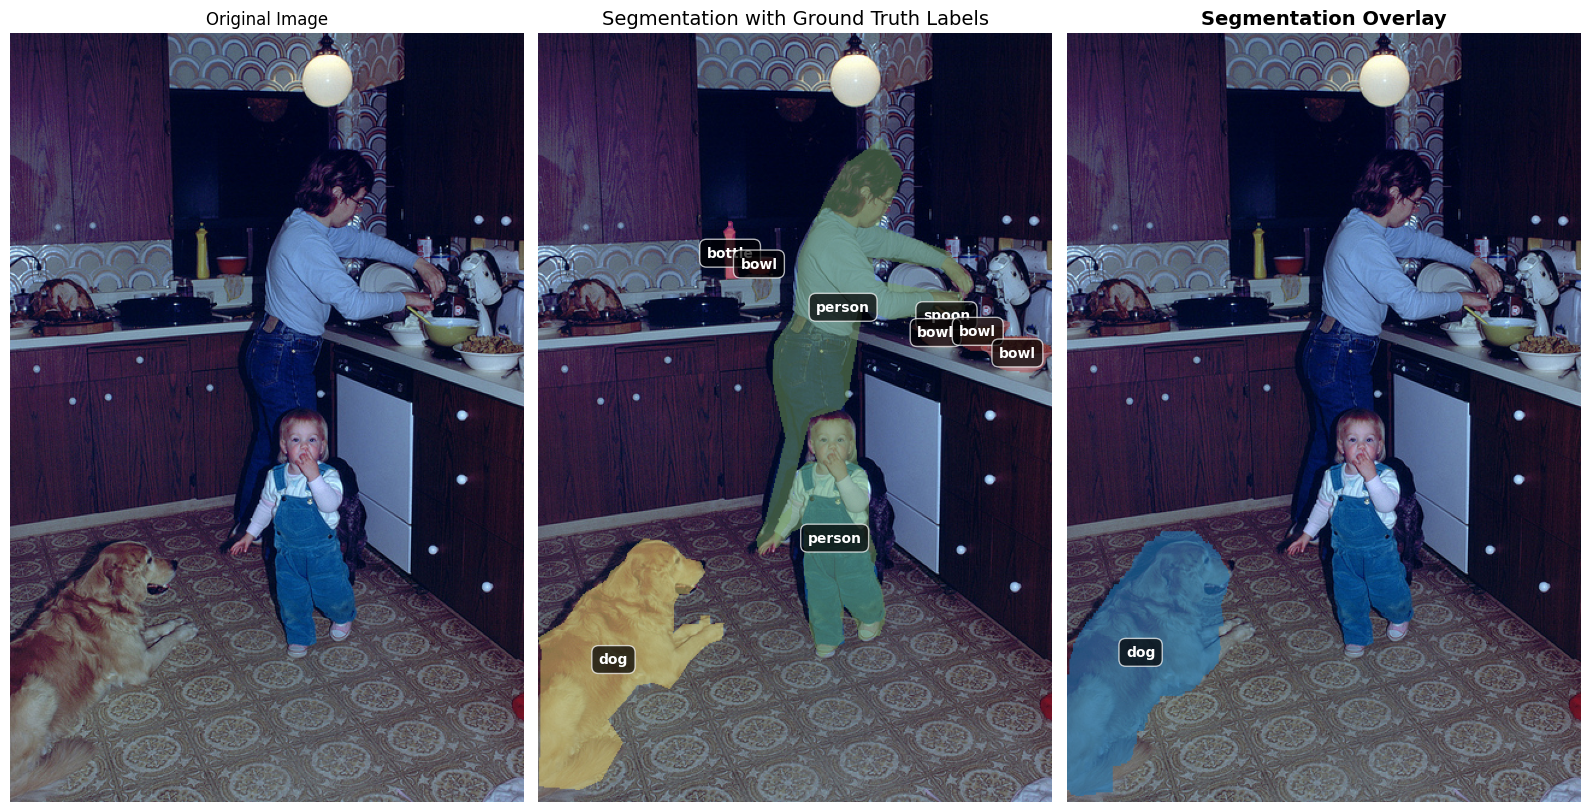

In [25]:
img_id = img_ids[0]
img_id = 494869
image = get_img(img_id, coco)
annotations = get_annotations_for_image(img_id, coco)
gt_objects, img_ids_per_cat = get_objects_from_annotations(annotations, coco)
# cats = list(set(gt_objects))
cats = ['dog']
fig, gt_overlay, pred_overlay, gt_masks, pred_masks = visualize_segmentation_with_labels(image, annotations, cats, coco, model, processor)
plt.show()

# miou, ious = calculate_miou(gt_masks, pred_masks)
# print(f"mIoU: {miou:.4f}")
# for class_id, iou in ious.items():
#     class_name = get_class_name(coco, class_id)
#     print(f"  Class {class_name} IoU: {iou:.4f}")

Get dog samples

In [26]:
ann_ids = coco.getAnnIds(imgIds=img_ids)
annotations = coco.loadAnns(ann_ids)
ground_truth_objects = set()
imgs_for_each_cat = defaultdict(list)
for ann in annotations:
    category_id = ann['category_id']
    cat_info = coco.loadCats(category_id)[0]
    class_name = cat_info['name']
    ground_truth_objects.add((category_id, class_name))
    imgs_for_each_cat[category_id].append(ann['image_id'])

In [32]:
imgs_for_each_cat[63][:10]

[491497, 219578, 219578, 96493, 23899, 340175, 578500, 578500, 578500, 366141]

Processing image 219578 for category 'couch'...
couch:
  Shape: torch.Size([352, 352])
  Mean probability: 0.3166
  Max probability: 0.8378
  Min probability: 0.0014


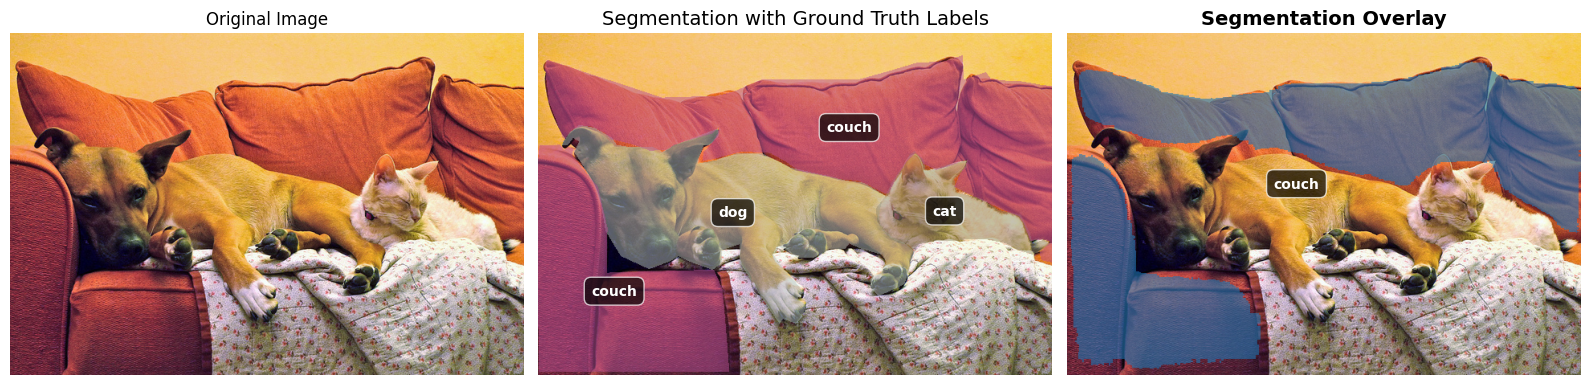

Processing image 219578 for category 'sofa'...
sofa:
  Shape: torch.Size([352, 352])
  Mean probability: 0.3161
  Max probability: 0.8459
  Min probability: 0.0013


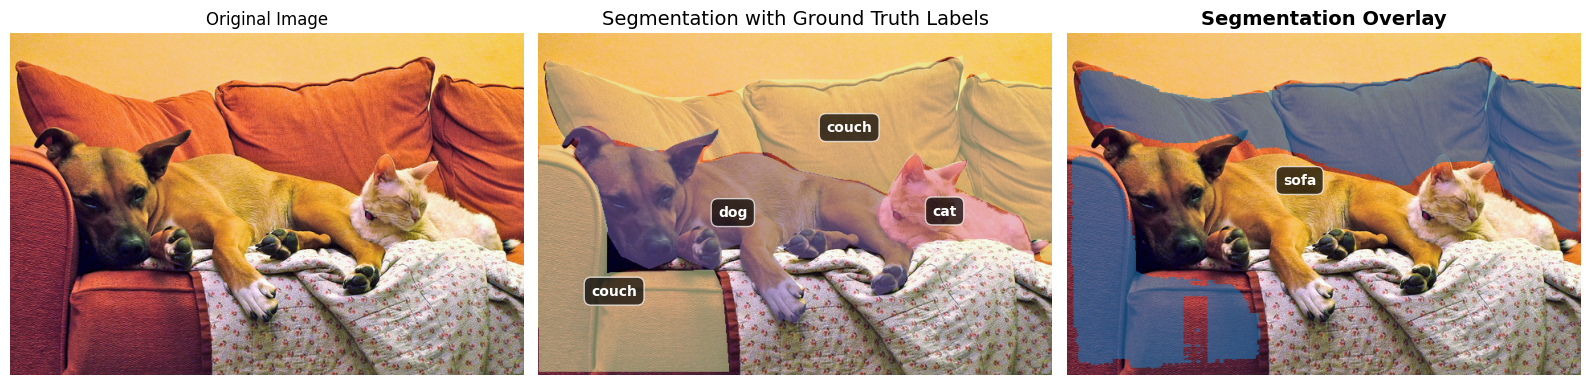

Processing image 219578 for category 'furniture'...
furniture:
  Shape: torch.Size([352, 352])
  Mean probability: 0.3053
  Max probability: 0.7338
  Min probability: 0.0032


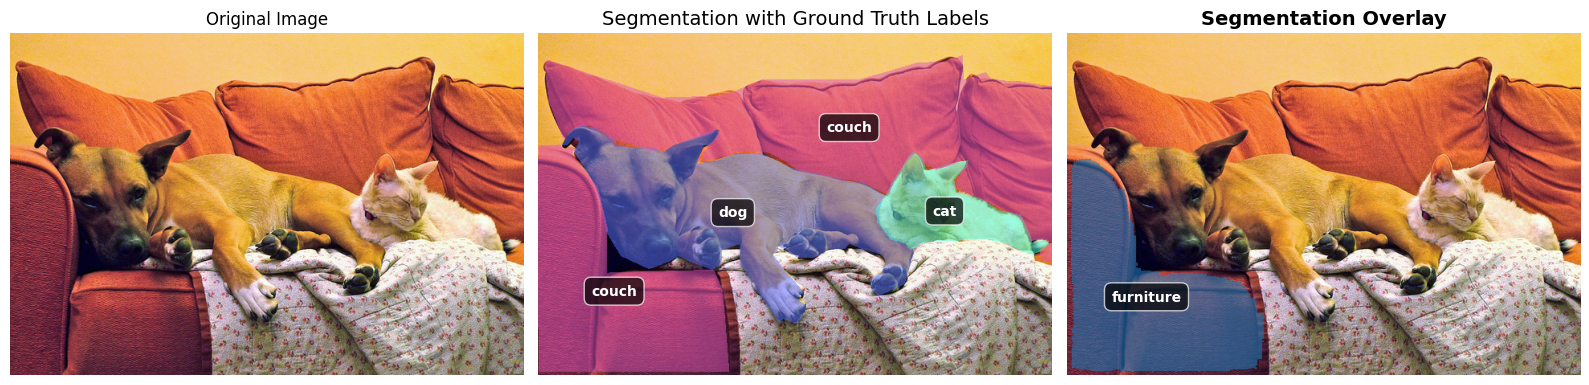

Processing image 219578 for category 'divan'...


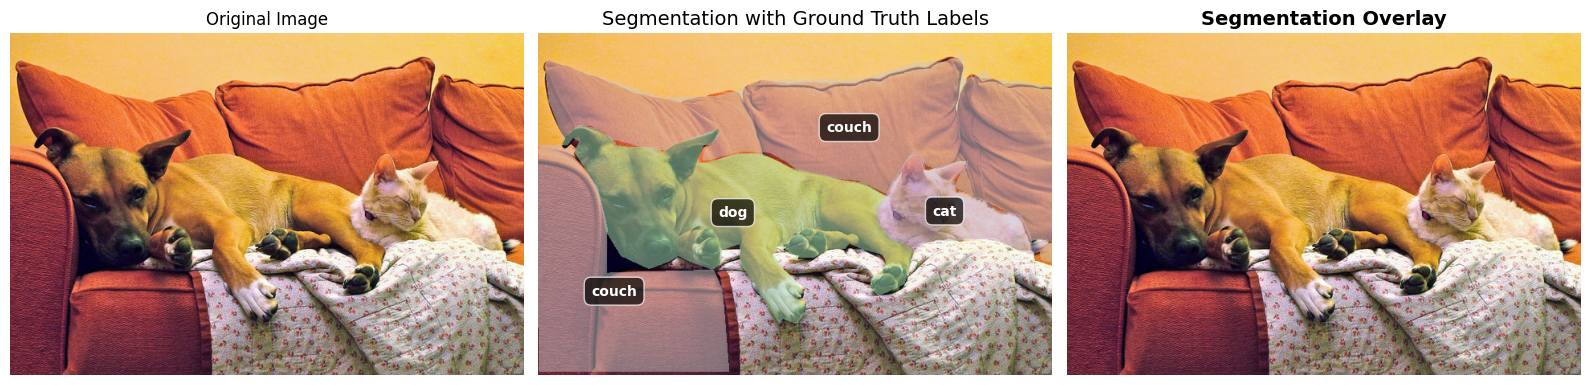

Processing image 219578 for category 'daybed'...
daybed:
  Shape: torch.Size([352, 352])
  Mean probability: 0.2792
  Max probability: 0.7047
  Min probability: 0.0018


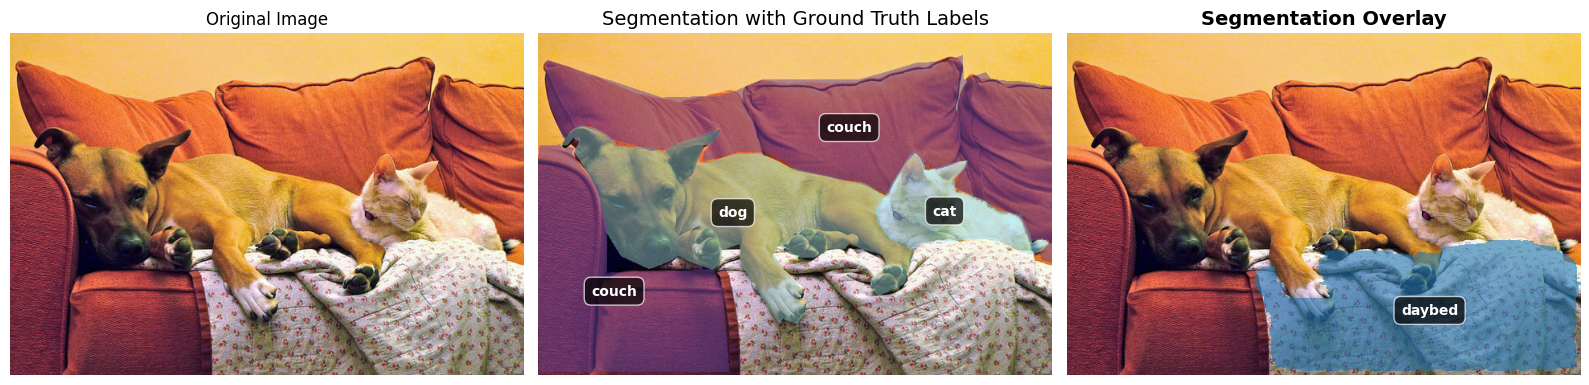

In [36]:
# cats = ['dog', 'canine', 'golden retriever', 'labrador retriever', 'bulldog', 'poodle', 'hound', 'pup', 'german shepherd', 'husky', 'mammal', 'animal', 'pet']
cats = ['couch', 'sofa', 'furniture', 'divan', 'daybed']
# img_ids = imgs_for_each_cat[63][:10]
img_ids = [219578]
for img_id in img_ids:
    for cat in cats:
        print(f"Processing image {img_id} for category '{cat}'...")
        image = get_img(img_id, coco)
        annotations = get_annotations_for_image(img_id, coco)
        gt_objects = get_objects_from_annotations(annotations, coco)
        # cats = list(set(gt_objects))
        cats = [cat]
        fig, gt_overlay, pred_overlay, gt_masks, pred_masks = visualize_segmentation_with_labels(image, annotations, cats, coco, model, processor)
        plt.show()

Processing image 219578 for category 'an object to sit on'...
an object to sit on:
  Shape: torch.Size([352, 352])
  Mean probability: 0.1102
  Max probability: 0.5625
  Min probability: 0.0008


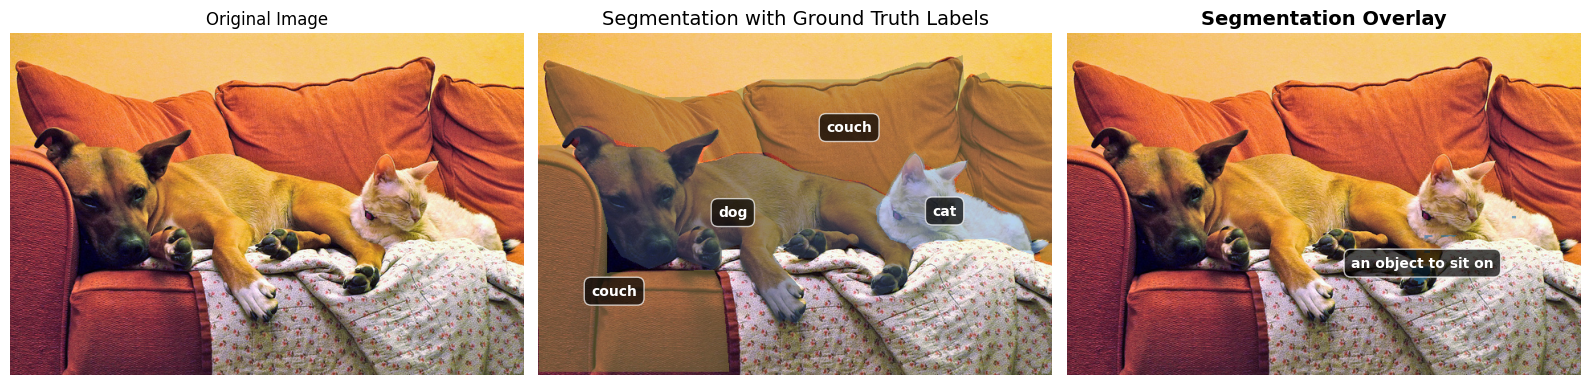

In [38]:
cats = ['an object to sit on']
# img_ids = imgs_for_each_cat[63][:10]
img_ids = [219578]
for img_id in img_ids:
    for cat in cats:
        print(f"Processing image {img_id} for category '{cat}'...")
        image = get_img(img_id, coco)
        annotations = get_annotations_for_image(img_id, coco)
        gt_objects = get_objects_from_annotations(annotations, coco)
        # cats = list(set(gt_objects))
        cats = [cat]
        fig, gt_overlay, pred_overlay, gt_masks, pred_masks = visualize_segmentation_with_labels(image, annotations, cats, coco, model, processor, desc=True)
        plt.show()